一些记号:<br>$n_u$:用户数量<br>$n_m$:物品数量<br>$r(i,j)=1$:如果用户j评价了物品i<br>$y^{(i,j)}$:当$r(i,j)=1$时,用户的评分<br>$n$:物品的特征数量<br>
$x^{(i)}$:第i个item的特征<br>
$w^{(i)}$:用户i对应的参数<br>
$m^{(j)}$:用户j评分的item数
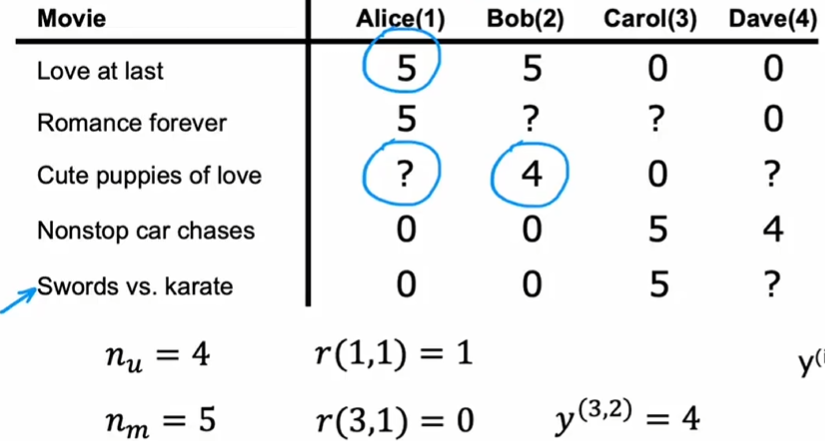

## 使用Per-item Features

这里其实有很深刻的背景（Embedding）

给item特征:<br>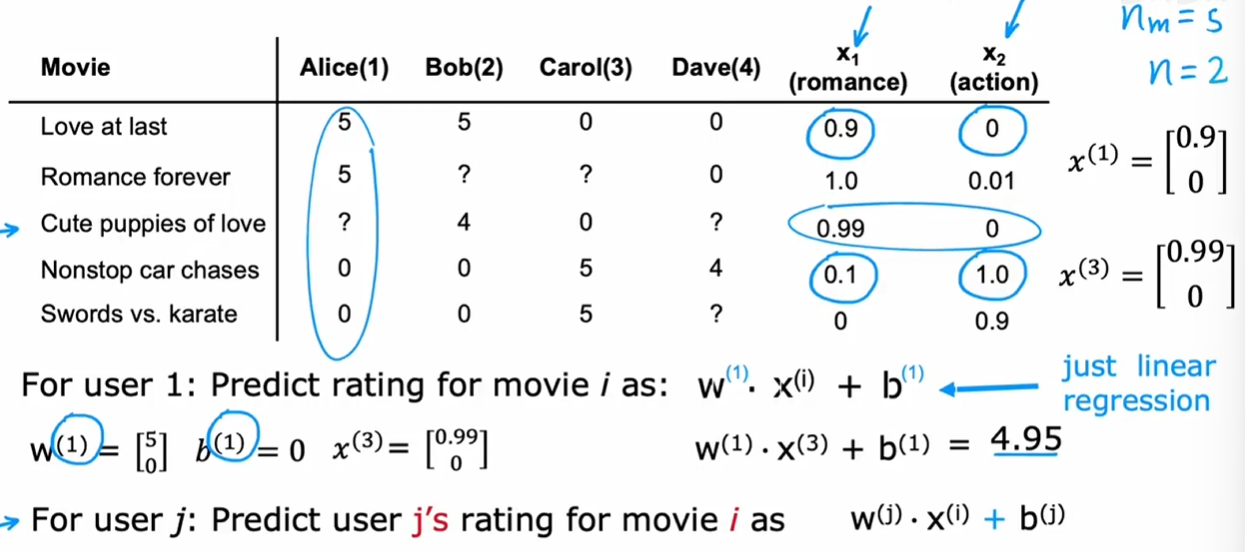

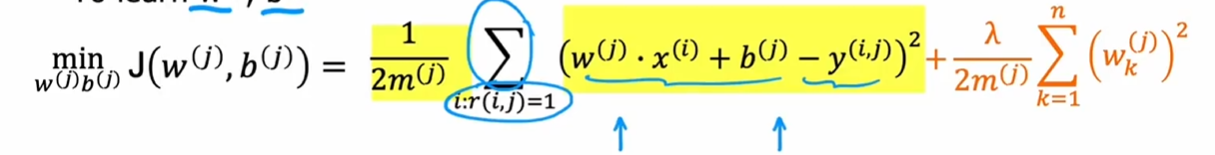<br>
在此我们可以不需要除以$m^{(j)}$(因为其是常数)

对于所有的用户,在给定item的特征时:$$J\!\left(\begin{matrix}w^{(1)},\ldots,w^{(n_u)}\\ b^{(1)},\ldots,b^{(n_u)}\end{matrix}\right)=\frac12\sum_{j=1}^{n_u}\left[\sum_{i:r(i,j)=1}\bigl((w^{(j)}\cdot x^{(i)}+b^{(j)}-y^{(i,j)})^2\bigr)+\frac{\lambda}{2}\sum_{k=1}^{n}(w_k^{(j)})^2\right]$$

## Collaborative Filter

在给定所有的**参数**时:$$J(x^{(1)},x^{(2)},\ldots,x^{(n_m)})=\frac12\sum_{i=1}^{n_m}\left[\sum_{j:r(i,j)=1}\bigl((w^{(j)}\cdot x^{(i)}+b^{(j)}-y^{(i,j)})^2\bigr)+\frac{\lambda}{2}\sum_{k=1}^{n}(x_k^{(i)})^2\right]$$注意,这里我们学习的是item的特征

强调一下我们要做什么：预测用户评分同时包含电影特征（根据用户的评分）

好的,但是我们怎么"给定"所有的参数呢?我们利用上一节课的知识,将两个Cost Function结合起来:
$$J(w,b,x)=\frac12\sum_{(i,j):r(i,j)=1}\bigl(w^{(j)}\cdot x^{(i)}+b^{(j)}-y^{(i,j)}\bigr)^2+\frac{\lambda}{2}\sum_{j=1}^{n_u}\sum_{k=1}^{n}\bigl(w_k^{(j)}\bigr)^2+\frac{\lambda}{2}\sum_{i=1}^{n_m}\sum_{k=1}^{n}\bigl(x_k^{(i)}\bigr)^2$$

使用梯度下降:(注意这里$x$是参数!)$$w_i^{(j)}=w_i^{(j)}-\alpha\frac{\partial}{\partial w_i^{(j)}}J(w,b,x)\\ b^{(j)}=b^{(j)}-\alpha\frac{\partial}{\partial b^{(j)}}J(w,b,x)\\  x_k^{(i)}=x_k^{(i)}-\alpha\frac{\partial}{\partial x_k^{(i)}}J(w,b,x)$$

**联合**是这个算法的精髓

**问题：模型在没看电影的情况下，只通过用户的评分是怎么得到电影的特征的？**<br>
未来的解答：你是把特征想象成了一个具体的东西（例如：爱情，科幻，动作...），但是模型学的是一种几何结构（说白了是一种相对关系，和绝对坐标没有关系）

## 二元标签

类似于逻辑回归:我们预测用户收藏(即$y^{(i,j)}=1$)的概率,线性回归加上sigmoid函数

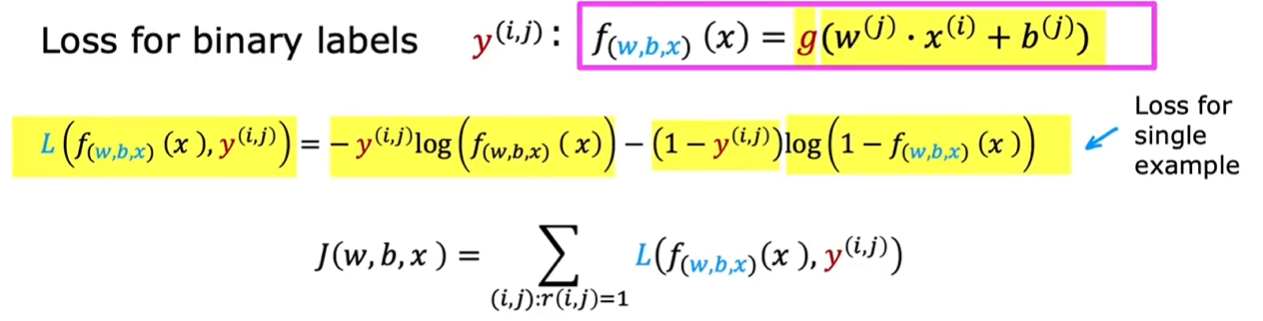

# 均值归一化

如果Eve没有评价任何电影,训练的结果就是w=0(训练项无贡献,但是惩罚项最小化为0).假如b又初始化为0,那么算法预测对所有的电影都是0,这是不合常理的<br>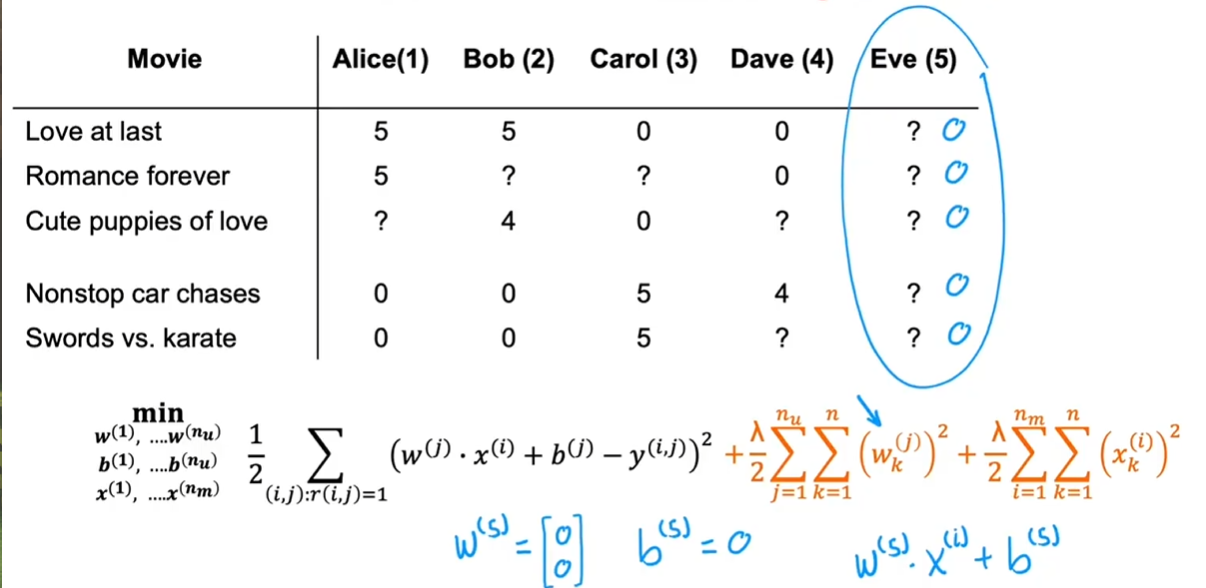

我们把评分表格变成矩阵,然后计算每一行的均值$\begin{bmatrix}
5 & 5 & 0 & 0 & ? \\
5 & ? & ? & 0 & ? \\
? & 4 & 0 & ? & ? \\
0 & 0 & 5 & 4 & ? \\
0 & 0 & 5 & 0 & ?
\end{bmatrix}$<br>
例如第一行就是$(5+5+0+0)/4=2.5$

我们得到均值向量$\mu =
\begin{bmatrix}
2.5 \\
2.5 \\
2 \\
2.25 \\
1.25
\end{bmatrix}$

我们新的评分矩阵就是每一列都减去$\mu$,所以线性回归部分也变为$w^{(j)}x^{(i)}+b^{(j)}+\mu_i$

# TensorFlow的实现

## TensorFlow可以进行一些基础的优化（自动微分）

In [3]:
import tensorflow as tf
from tensorflow import keras

In [14]:
#例如我们要优化一个训练样本的线性回归（b=0）
w = tf.Variable(3.0) #设置w初始为3.0告诉TensorFlow此为优化对象
x = 1.0
y = 1.0 #需要预测y为0.1
alpha = 0.03
itera = 100
for iter in range(itera):
    #告诉Tensorflow需要如何计算梯度
    with tf.GradientTape() as tape:
        fwb = w*x
        costJ = (fwb - y)**2
    #自动微分
    [dJdw] = tape.gradient(costJ, [w])
    w.assign_add(-alpha *dJdw) #tf.variables需要特殊的函数修饰

In [15]:
print(w)

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=1.0041098594665527>


## 联合过滤算法的实现

见 Lab

# Finding related items

两个特征向量的相似度可以如下定义：$$\sum^n_{l=1}(x^{(k)}_l-x^{(i)}_l)^2$$

# 协同过滤的局限性

冷启动问题
1. 新的电影，没什么人评价
2. 新用户，没怎么评价电影

不全面的信息
1. 用户的各种信息
2. 电影的各种信息

# Collaborative Filtering and Content-based Filtering

再次重申一遍协同过滤的过程：我们的数据是一张用户/items的评分表（并非每个item都被评分过）<br>
首先我们先创建一些item的特征（注意这是“不可解释”的。至于这些特征到底是什么，没人知道（具体原因和旋转不变性有关））<br>
然后使用评分作为数据，我们会得到一个从`(user_id, item_id)`到电影评分的函数

相比于联合过滤，内基过滤根据用户和items的特征来推荐

一些记号：
1. $x_u^{(j)}$：用户j的特征（item的同理）

不同于前者的$w^{(j)}\cdot x^{(i)}+b^{(j)}$此处我们使用$v_u^{(j)}\cdot v_m^{(i)}$这两个都是向量，他们从对应的特征$x^{(i)}$计算得到（这实际上就是点积相似度（有点像Transformer的Q，K））

# 应用于内基过滤的Deep Learning

如何从x得到v——深度学习：<br>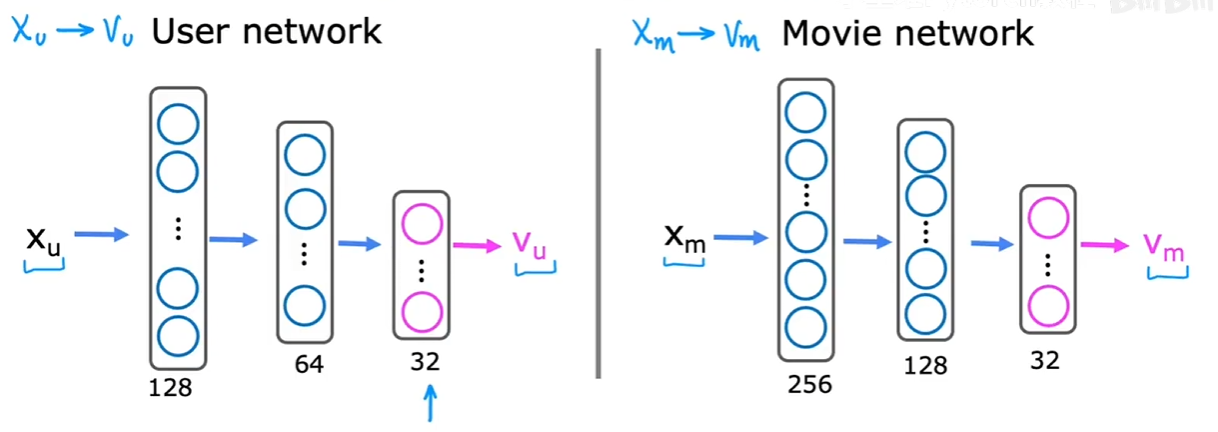

注意我们最终使用点积，所以输出层的神经元数必须一样

如果是使用二进制标签的特征，就是利用sigmoid函数算等于1的概率

Cost Function:$$J=\sum_{(i,j):\,r(i,j)=1}\left(v_u^{(j)}\cdot v_m^{(i)}-y^{(i,j)}\right)^2+\text{NN regularization term}$$（此处y是评分）

Finding related items这一章中：通过两个向量差的L2范数的平方得到相关性

Andrew Ng说：仔细考虑特征是很重要的

一个包含大量不同电影的目录，运行会非常慢

# 从大型项目中推荐

注意，在实际的工程中，常常使用“预先计算”提前计算好相关数据

需要被推荐的的items可能有上百万，这也意味着我们要前向传播上百万次的神经网络，这是不可行的

大规模推荐系统有两个步骤：检索与排序
1. 在检索步骤中生成一个包含大量合理候选项目的列表（可以通过用户才看的10个电影，找几个最相似的电影），其目标是确保广泛的覆盖
2. 然后将之取出重复项（以及用户观看过的），得到一个推荐列表
3. 最后把大约100个items的v（预先计算好）和即时计算的用户的v进行点积，然后排序

# 内基过滤的TensorFlow实现

见Lab